In [ ]:
# To run cells in this notebook, update the location of the MVTec dataset in the variable below

data_location = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec'


# Data Quality Assessment for Data Exploration Report

In [5]:
# Libraries

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random
import math


In [33]:
# Functions

def check_for_duplicate_images(obj: str, dataset: str) -> list:
    '''
    Print number of duplicate images found (if any)
    args:
        obj: one of the objects from the MVTec dataset
        dataset: train or test
    '''
    cat_path = f"{data_location}/{obj}/{dataset}"
    dir_list = os.listdir(cat_path)

    all_imgs = []
    for cat in dir_list:
        img_path = os.path.join(cat_path, cat)
        img_list = os.listdir(img_path)
    
        for imgfile in img_list:
            img = cv2.imread(os.path.join(img_path, imgfile), cv2.IMREAD_GRAYSCALE)
            all_imgs.append(img)

    imgs_stacked_3D = np.dstack(all_imgs)
    shape_all = imgs_stacked_3D.shape
    unique_imgs = np.unique(imgs_stacked_3D, axis=2)
    shape_unique = unique_imgs.shape
    if (shape_unique == shape_all):
        print('All image arrays are unique')
    else:
        duplicate_count = imgs_stacked_3D.shape[2] - unique_imgs.shape[2]
        print(f'{duplicate_count} duplicates image arrays have been found.')

    return imgs_stacked_3D


def plot_all_defect_ratios(obj: str, boxplot: bool = False) -> None:
    obj_path = f"/home/suzy/datascientest/anomalie_proj/datasets/MVTec/{obj}/ground_truth"
    anomalie_list = os.listdir(obj_path)

    plt.figure(figsize=(12, 10))
    i = 1
    for defect in anomalie_list:
        mask_path = os.path.join(obj_path, defect)
        mask_list = os.listdir(mask_path)
    
        mask_ratios = []
        for file in mask_list:
            mask = cv2.imread(os.path.join(mask_path, file), cv2.IMREAD_GRAYSCALE)
            mask_ratios.append(round(np.count_nonzero(mask) / (mask.shape[0]*mask.shape[1]), 4))
        plt.subplot(math.ceil(len(anomalie_list)/2), 2, i)
        plt.title(f"Mask ratios for {obj} {defect} anomalie")
        if boxplot:
            plt.boxplot(mask_ratios)
        else:
            plt.bar(mask_list, mask_ratios)
        plt.xticks(rotation=90)
        i += 1
    
    if boxplot:
        plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.3, wspace=0.4, hspace=0.6)
    else:
        plt.subplots_adjust(left=0.1, right=0.9, top=1.5, bottom=0.7, wspace=0.4, hspace=1.5)
        
    plt.show()
 

## 1. Checking for duplicate images in the MVTec dataset

Duplicate data can cause bias in training. All images are compared for each object type to check for any duplicate images in the train and test sets. This analysis also allows us to check that all files can be read and that none are corrupt.

Checks for duplicate images are performed by converting all images to black and white and then creating a 3D numpy array of all 2D image arrays for a given object type and then using numpy's in-built unique function to check for duplicates.


In [6]:
data_path = f'{data_location}'
all_objects = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
print(f'Checking for duplicate images in object categories:\n {all_objects}\n')

all_in_cat_unique = []
for obj in all_objects:
    print(f'\n Checking for duplicates in train images for {obj}')
    train_imgs_array = check_for_duplicate_images(obj, 'train')
    print(f'Checking for duplicates in test images for {obj}')
    test_imgs_array = check_for_duplicate_images(obj, 'test')
    imgs_stacked_3D = np.concatenate([test_imgs_array, train_imgs_array], -1)
    unique_imgs = np.unique(imgs_stacked_3D, axis=2)
    print('Checking there are no duplicates between train and test sets:')
    print(imgs_stacked_3D.shape == unique_imgs.shape)
    all_in_cat_unique.append(imgs_stacked_3D.shape == unique_imgs.shape)

print('\n Confirming no duplicates found for any category:')
print(set(all_in_cat_unique))


Checking for duplicate images in object categories:
 ['metal_nut', 'screw', 'tile', 'transistor', 'bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'pill', 'toothbrush', 'wood', 'zipper']


 Checking for duplicates in train images for metal_nut
All image arrays are unique
Checking for duplicates in test images for metal_nut
All image arrays are unique
Checking there are no duplicates between train and test sets:
True

 Checking for duplicates in train images for screw
All image arrays are unique
Checking for duplicates in test images for screw
All image arrays are unique
Checking there are no duplicates between train and test sets:
True

 Checking for duplicates in train images for tile
All image arrays are unique
Checking for duplicates in test images for tile
All image arrays are unique
Checking there are no duplicates between train and test sets:
True

 Checking for duplicates in train images for transistor
All image arrays are unique
Checking for duplicates in 

In [7]:
# Check function used above with data where I have intentionally put a duplicate image

with_duplicate_test_arrays = check_for_duplicate_images('function_test', 'misc_cable_imgs')


1 duplicates image arrays have been found.


## 2. Checking for incorrect anomaly labelling in the MVTec dataset

To check for incorrect labelling of anomaly type (which could lead to poorer performance of our models), the size of the anomaly as represented in the masks for each anomaly type is presented in a box and whisker plot. The corresponding image for any mask size outlier for any given anomaly type is then visually inspected to ensure that the anomaly was correctly labelled.

Anomaly sizes are obtained from the masks by firstly converting images to black and white and then counting the number of elements in the image array that have non-zero values (as the background of these images is black, as shown in the image below).


Image randomly chosen: 004_mask.png
Size of image: (1024, 1024, 3)


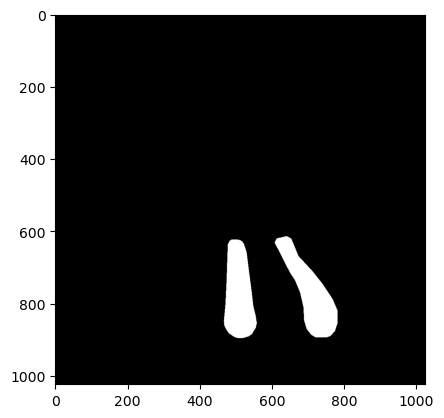

In [10]:
img_path = f'{data_location}/transistor/ground_truth/cut_lead'

img_list = os.listdir(img_path)
img_file = random.choice(img_list)
img_array = cv2.imread(os.path.join(img_path, img_file), cv2.IMREAD_COLOR)
print(f'Image randomly chosen: {img_file}')
print(f"Size of image: {img_array.shape}")
plt.imshow(img_array)
plt.show()


In [11]:
print(f'Checking for incorrect labels in object categories:\n {all_objects}\n')


Checking for incorrect labels in object categories:
 ['metal_nut', 'screw', 'tile', 'transistor', 'bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'pill', 'toothbrush', 'wood', 'zipper']



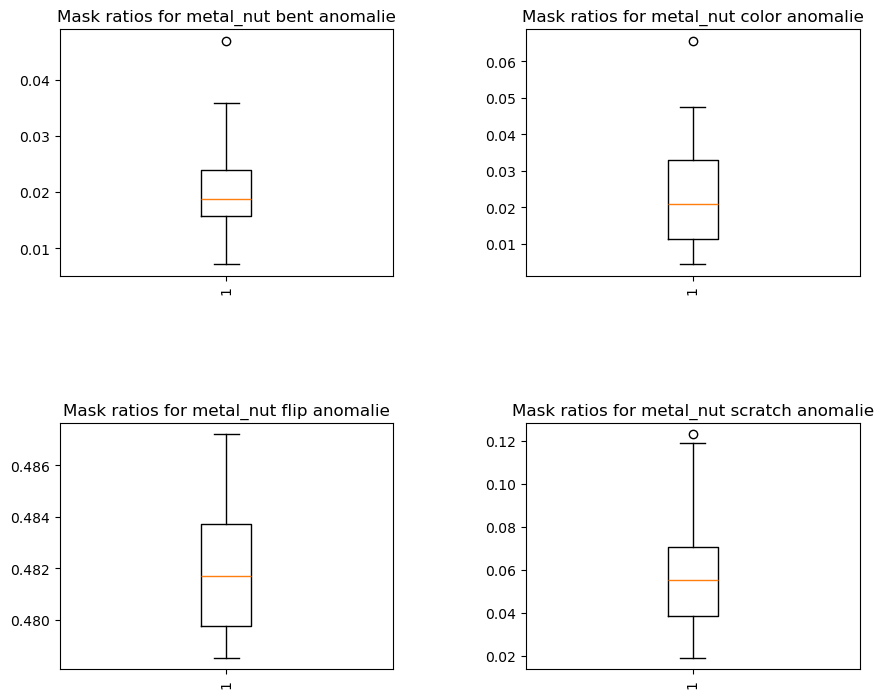

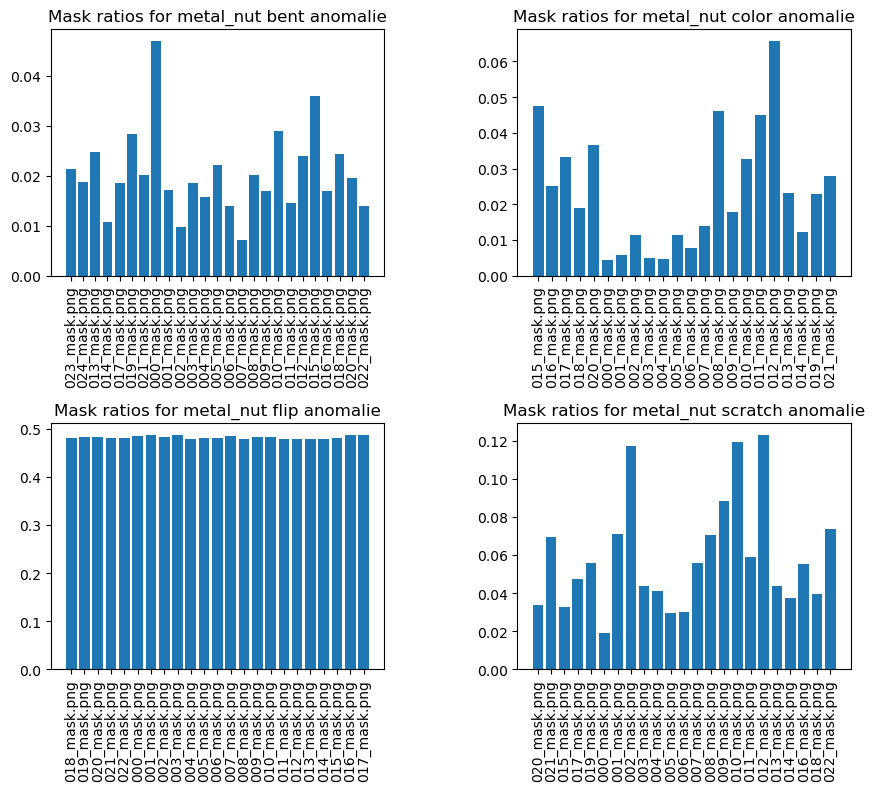

In [18]:
# metal_nut

plot_all_defect_ratios('metal_nut', boxplot=True)
plot_all_defect_ratios('metal_nut', boxplot=False)


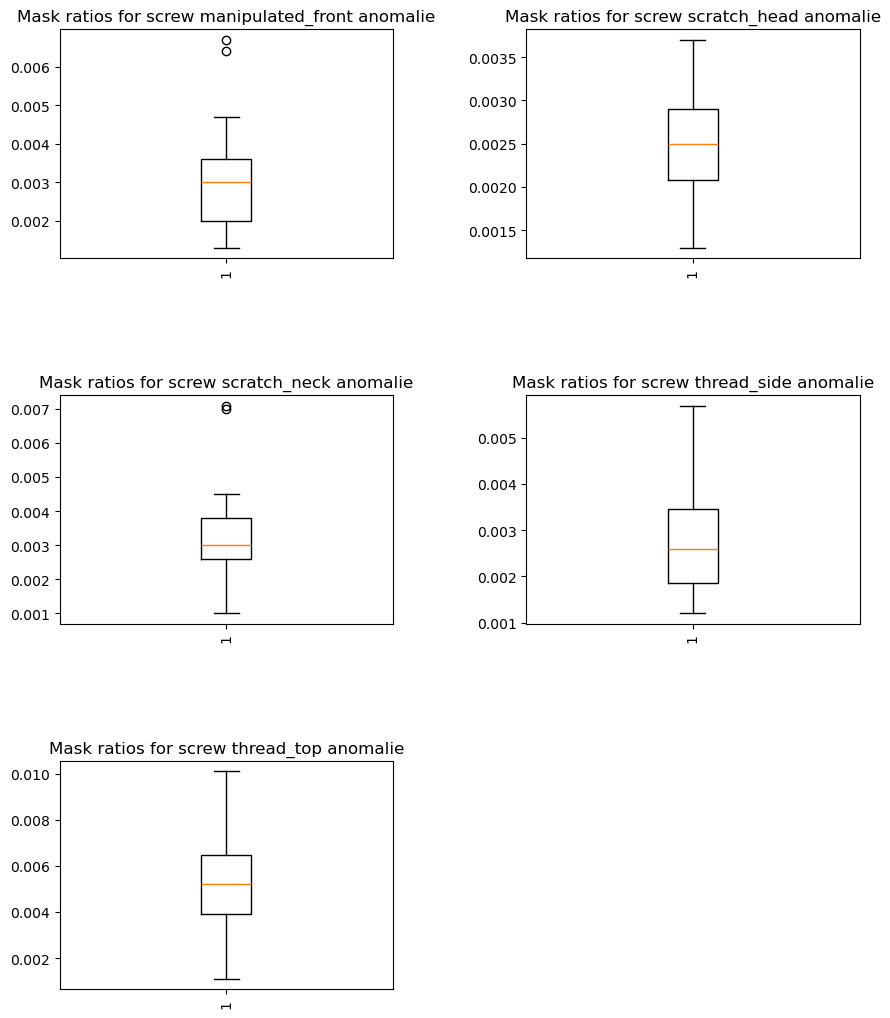

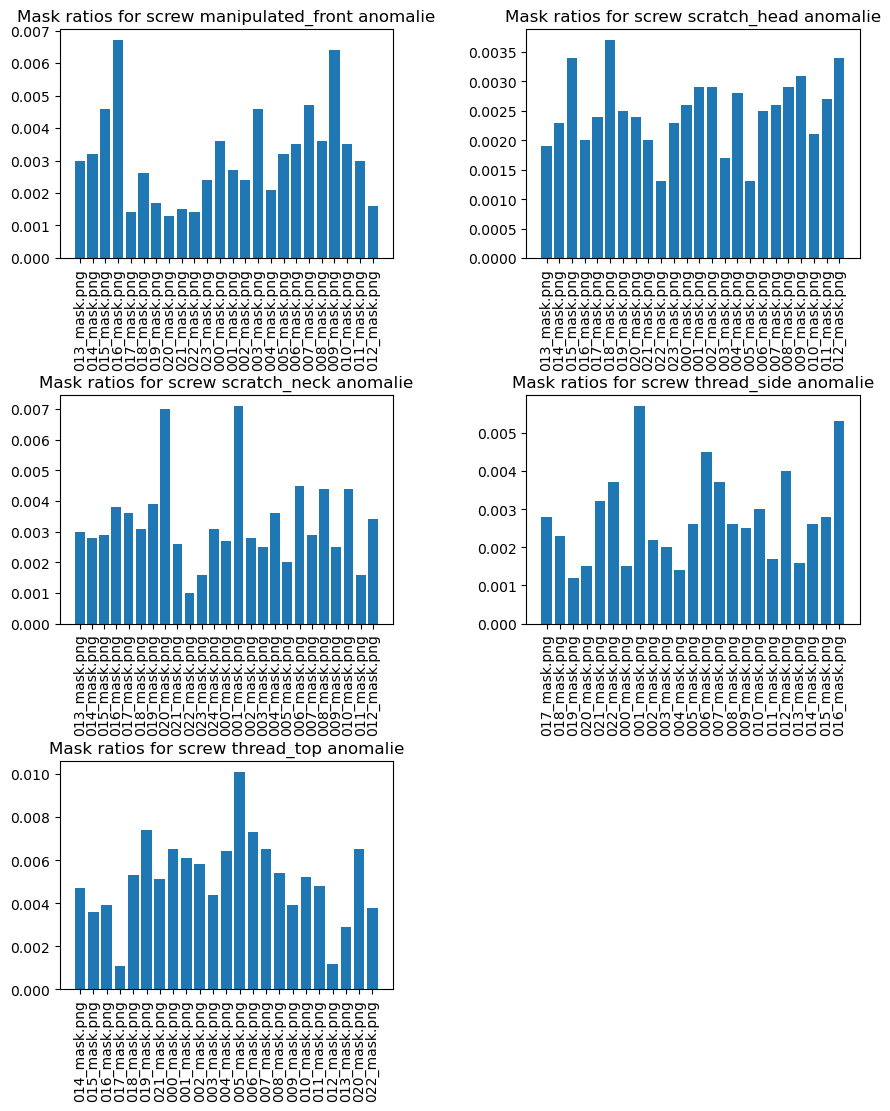

In [12]:
# screw

plot_all_defect_ratios('screw', boxplot=True)
plot_all_defect_ratios('screw', boxplot=False)


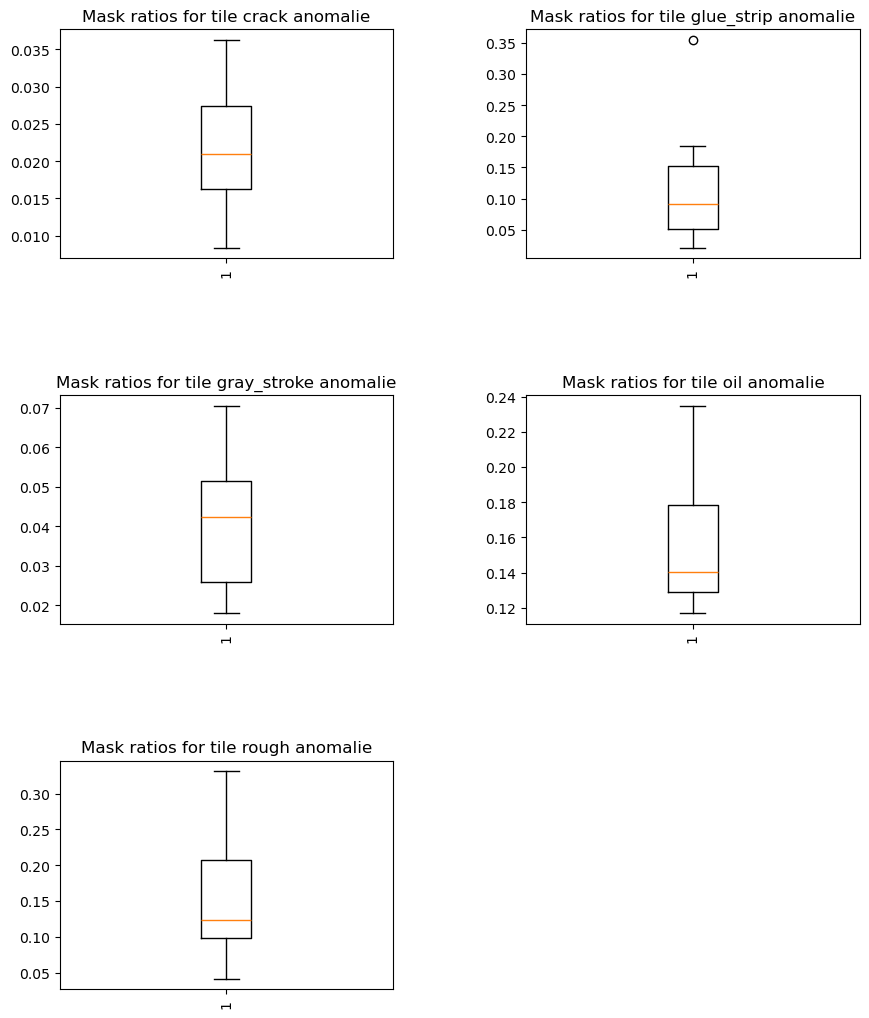

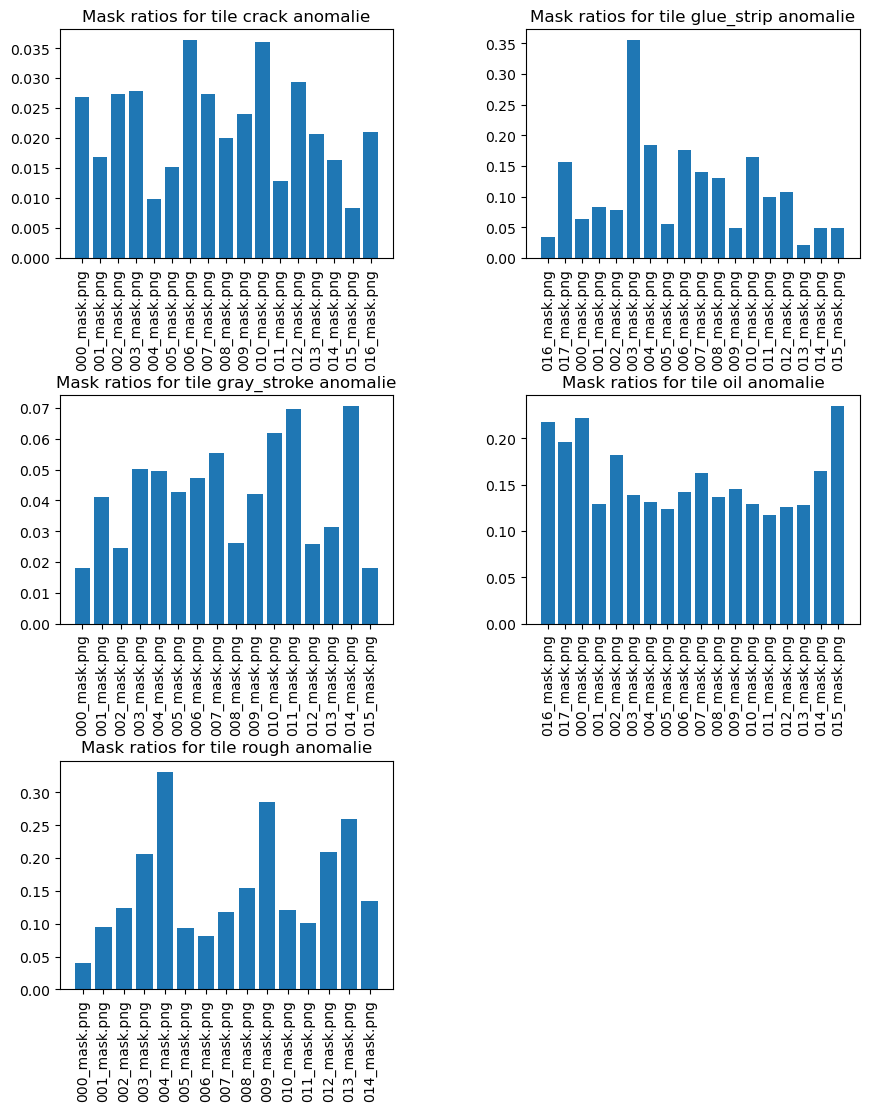

In [13]:
# tile

plot_all_defect_ratios('tile', boxplot=True)
plot_all_defect_ratios('tile', boxplot=False)


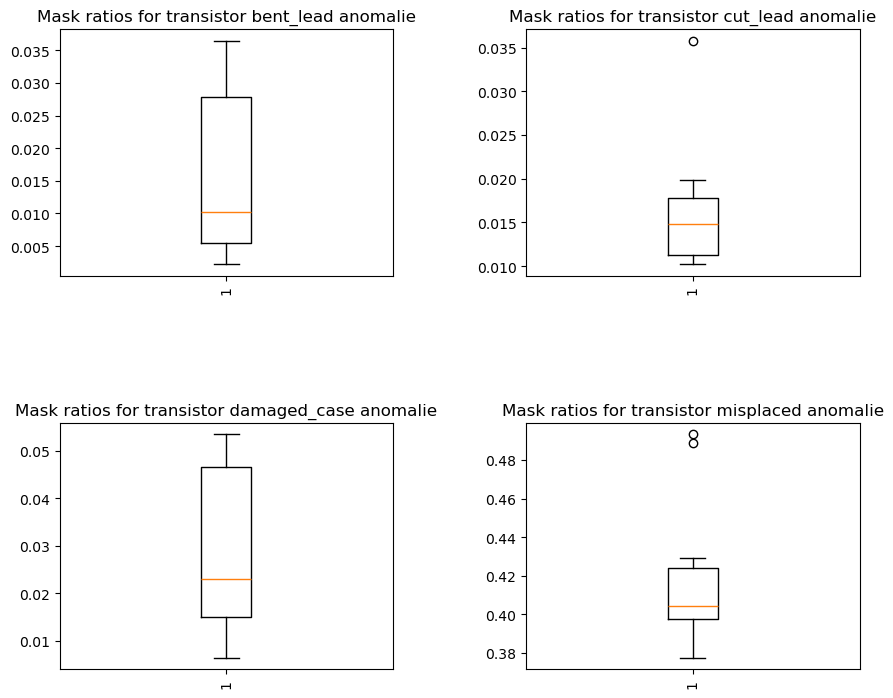

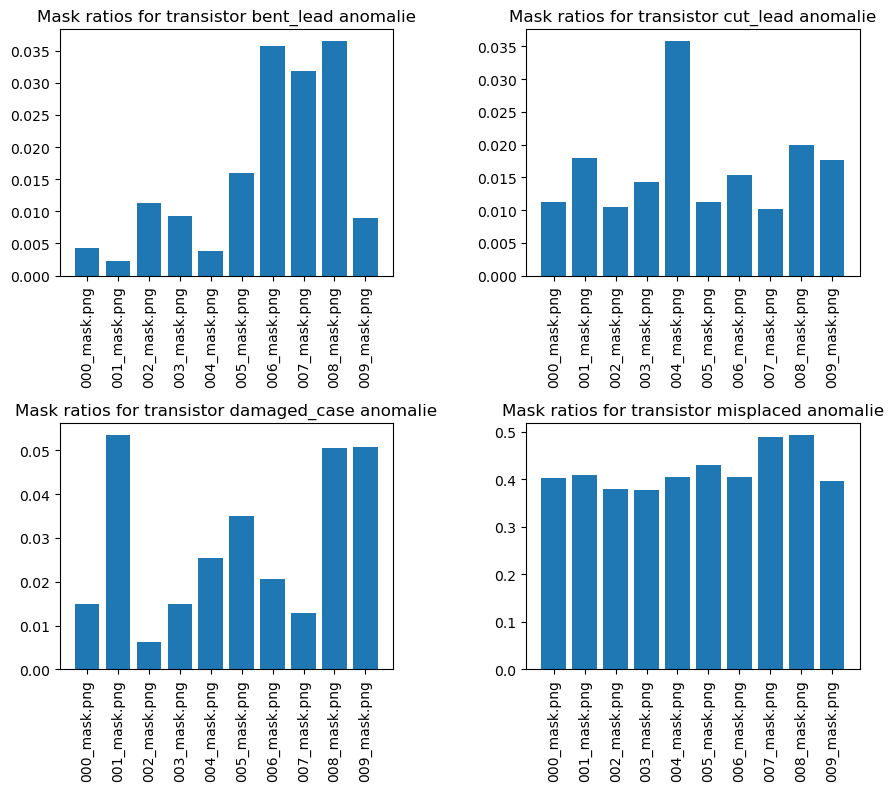

In [20]:
# transistor

plot_all_defect_ratios('transistor', boxplot=True)
plot_all_defect_ratios('transistor', boxplot=False)


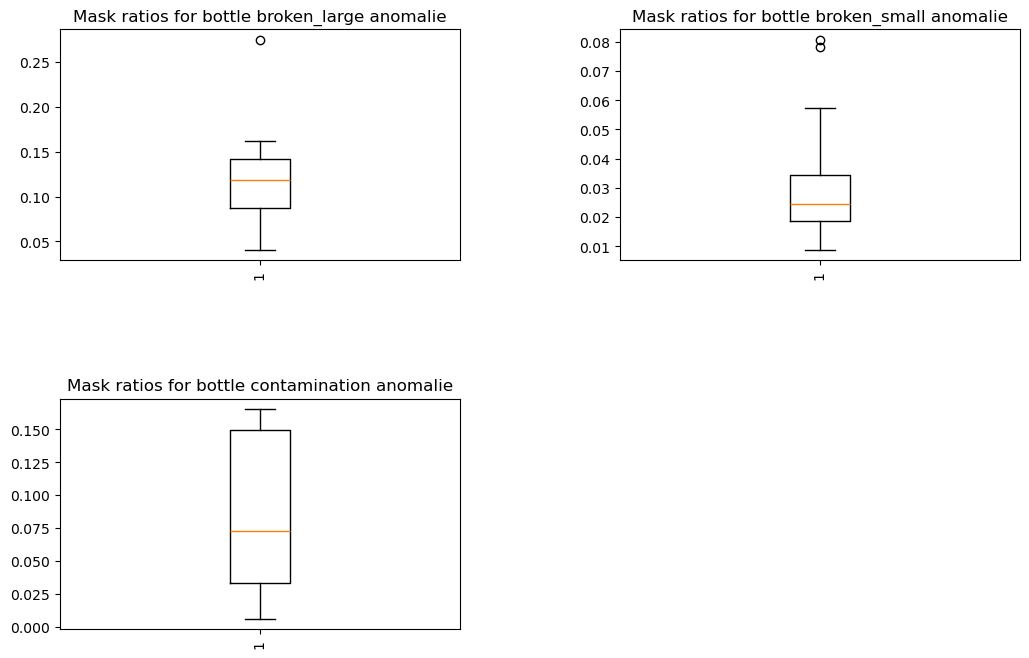

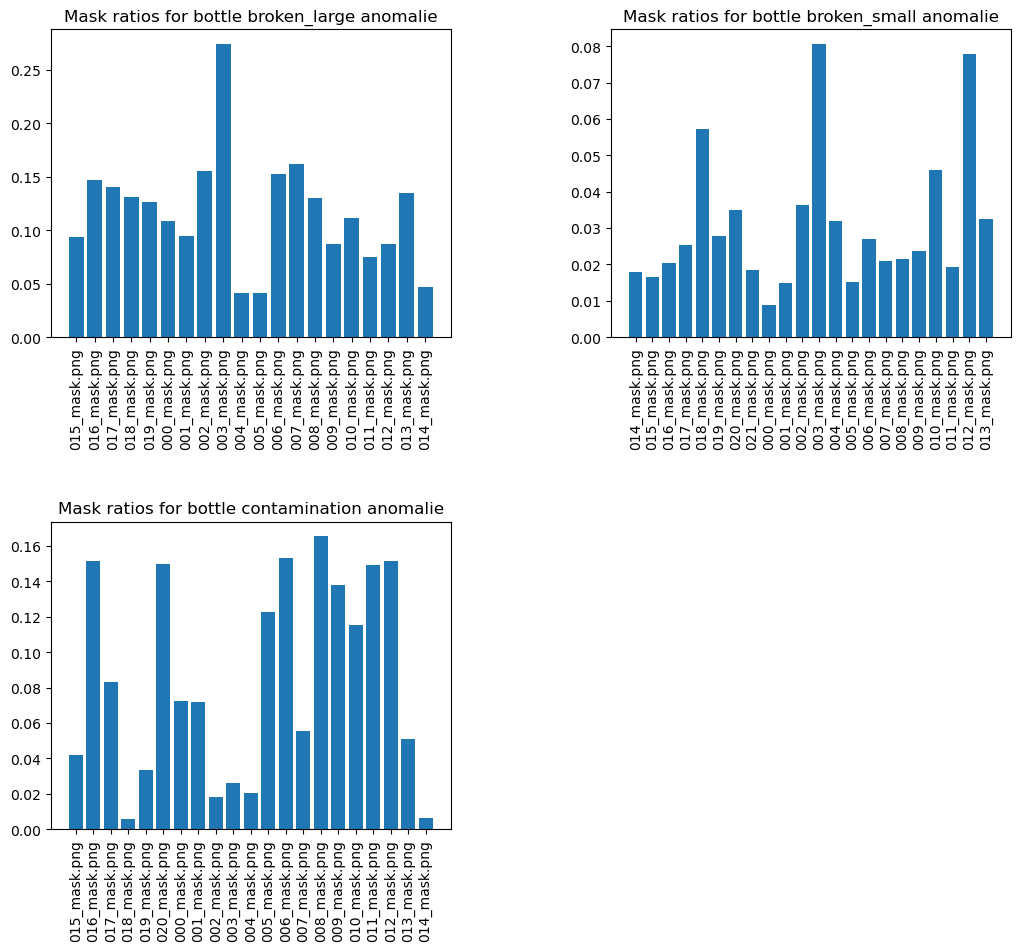

In [30]:
# bottle

plot_all_defect_ratios('bottle', boxplot=True)
plot_all_defect_ratios('bottle', boxplot=False)


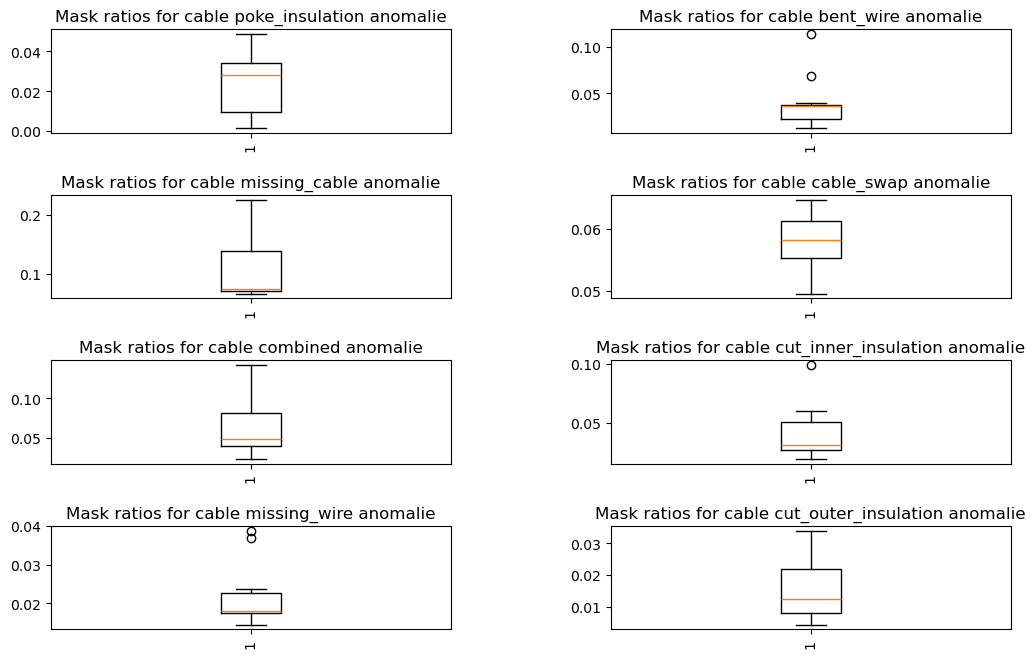

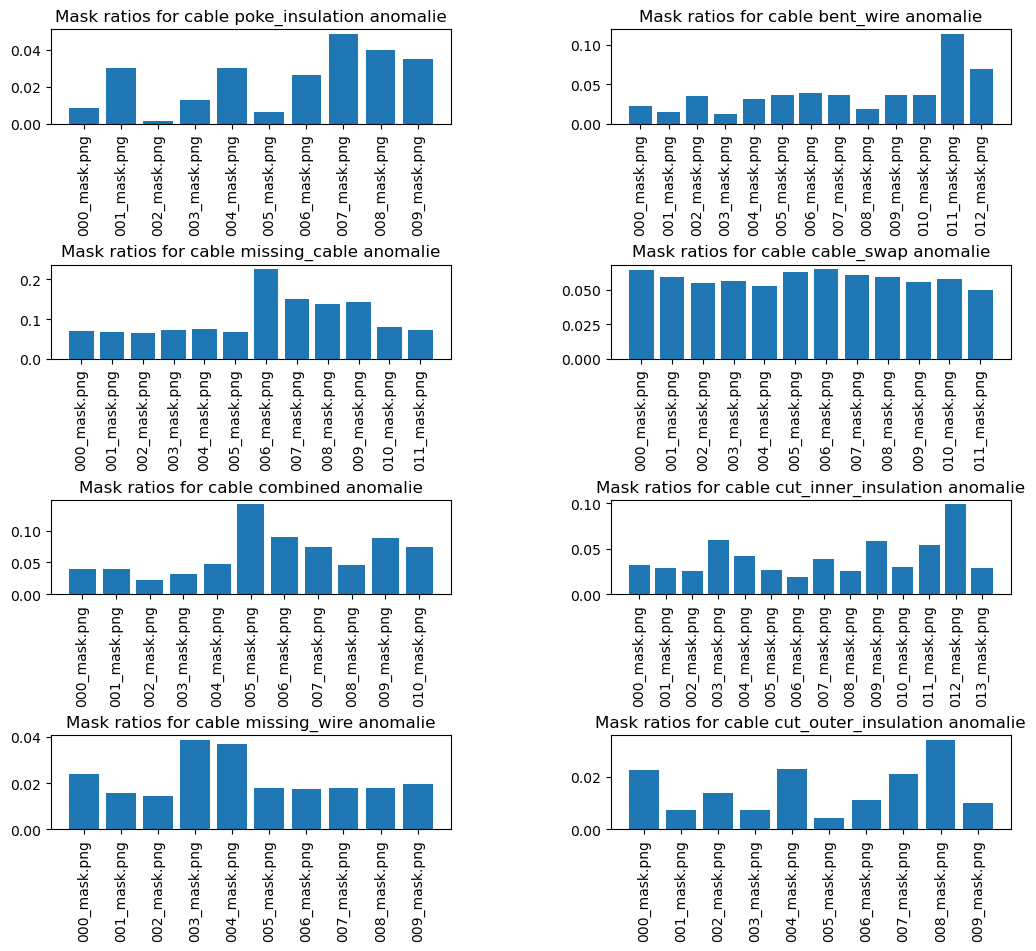

In [34]:
# cable

plot_all_defect_ratios('cable', boxplot=True)
plot_all_defect_ratios('cable', boxplot=False)


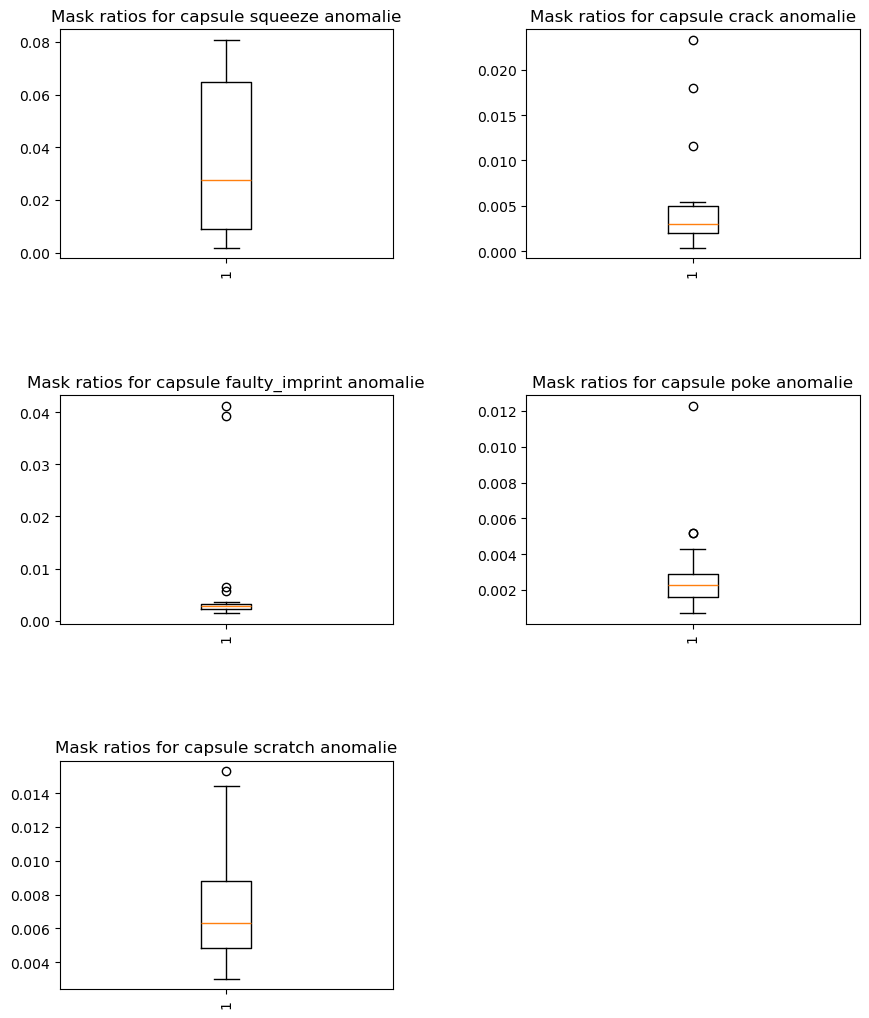

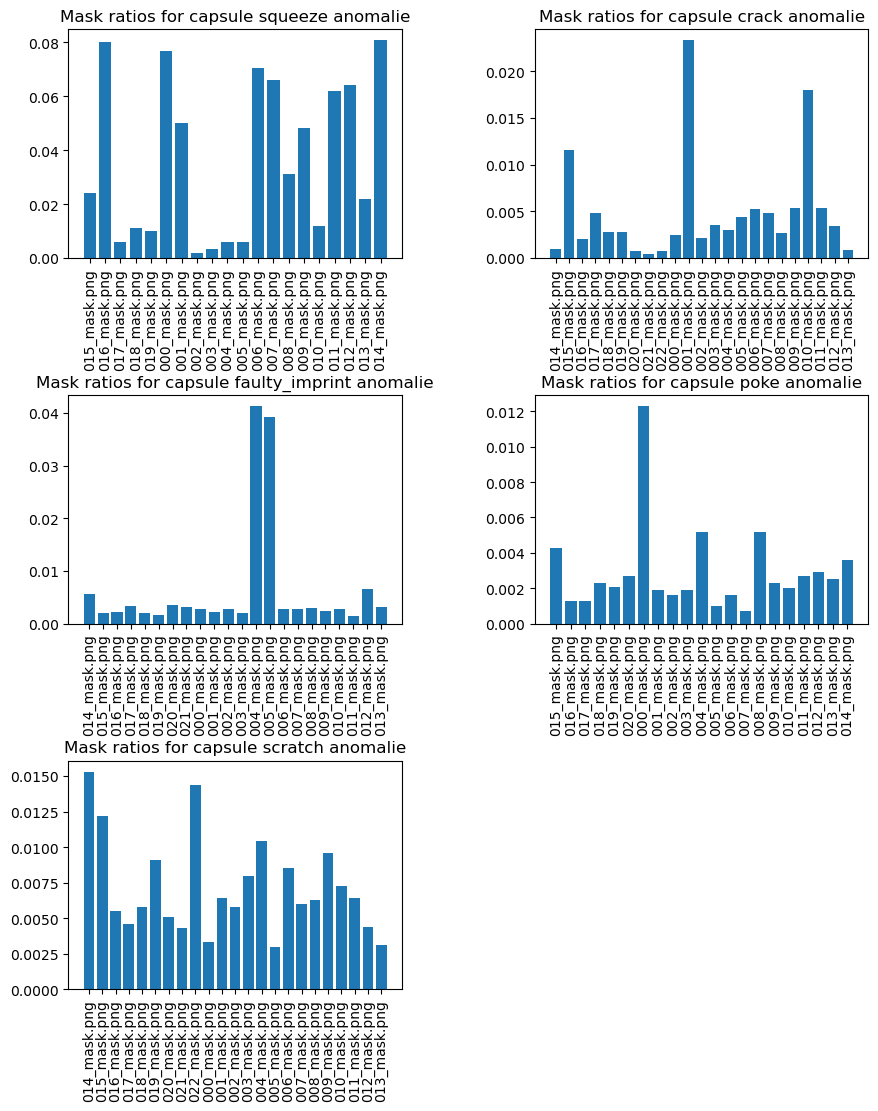

In [16]:
# capsule

plot_all_defect_ratios('capsule', boxplot=True)
plot_all_defect_ratios('capsule', boxplot=False)


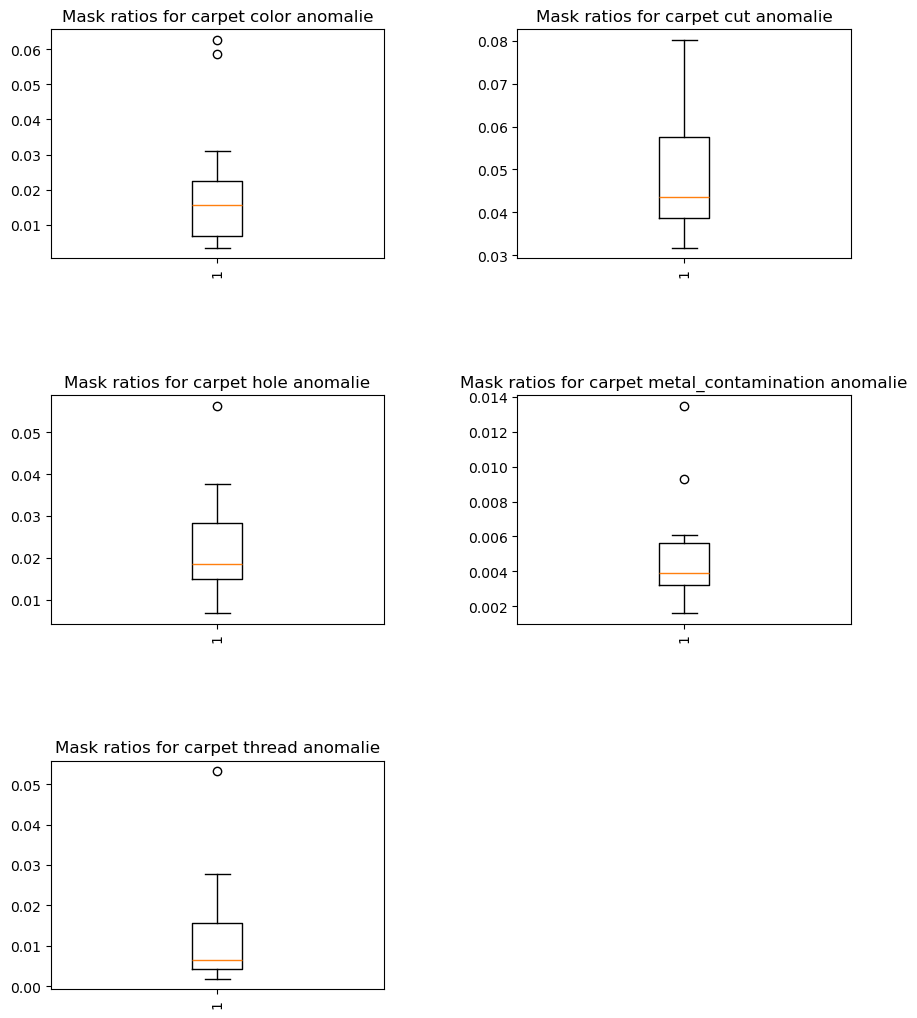

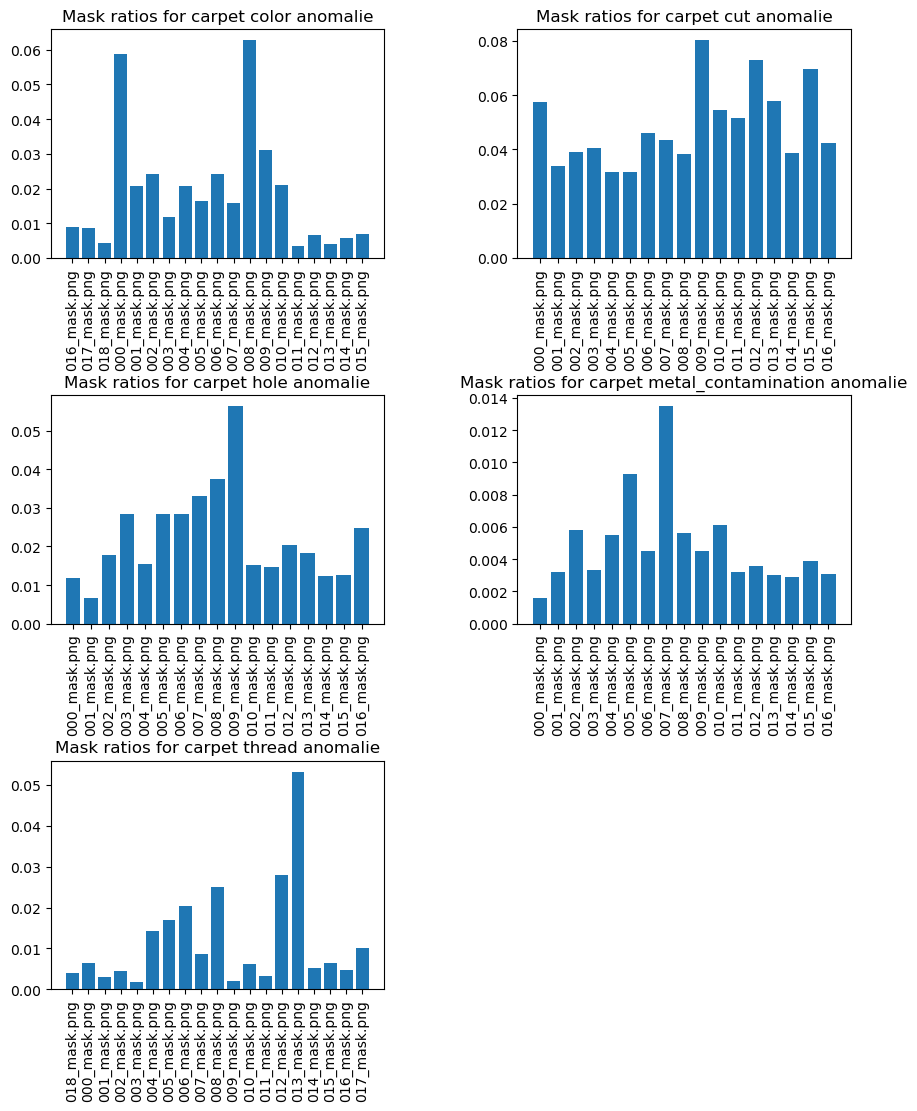

In [17]:
# carpet

plot_all_defect_ratios('carpet', boxplot=True)
plot_all_defect_ratios('carpet', boxplot=False)


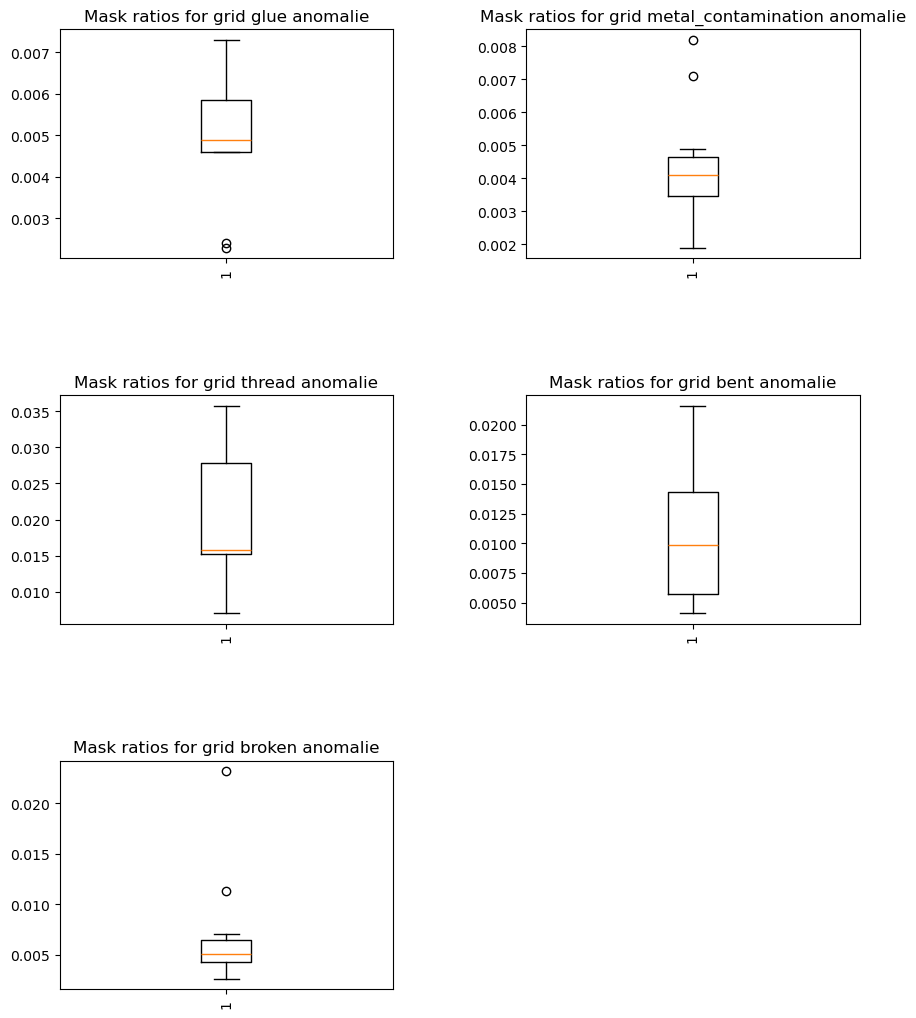

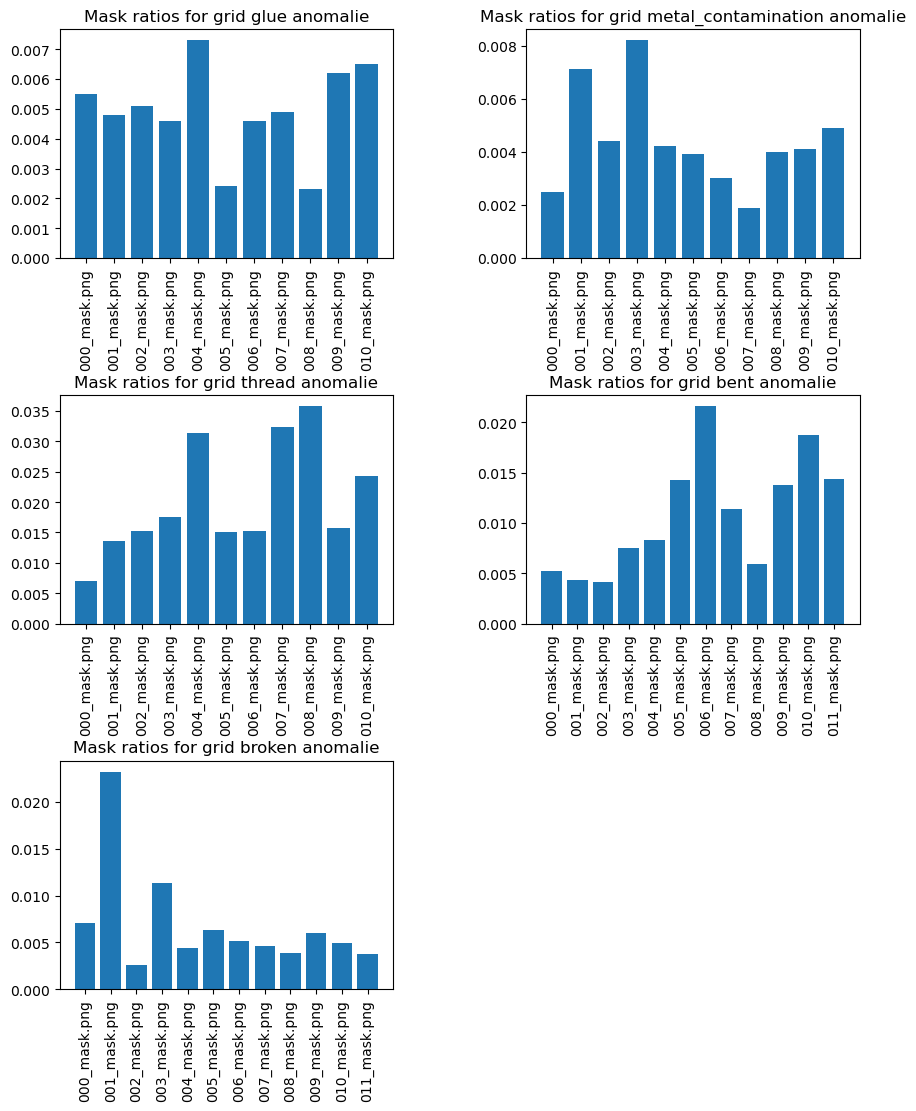

In [18]:
# grid

plot_all_defect_ratios('grid', boxplot=True)
plot_all_defect_ratios('grid', boxplot=False)


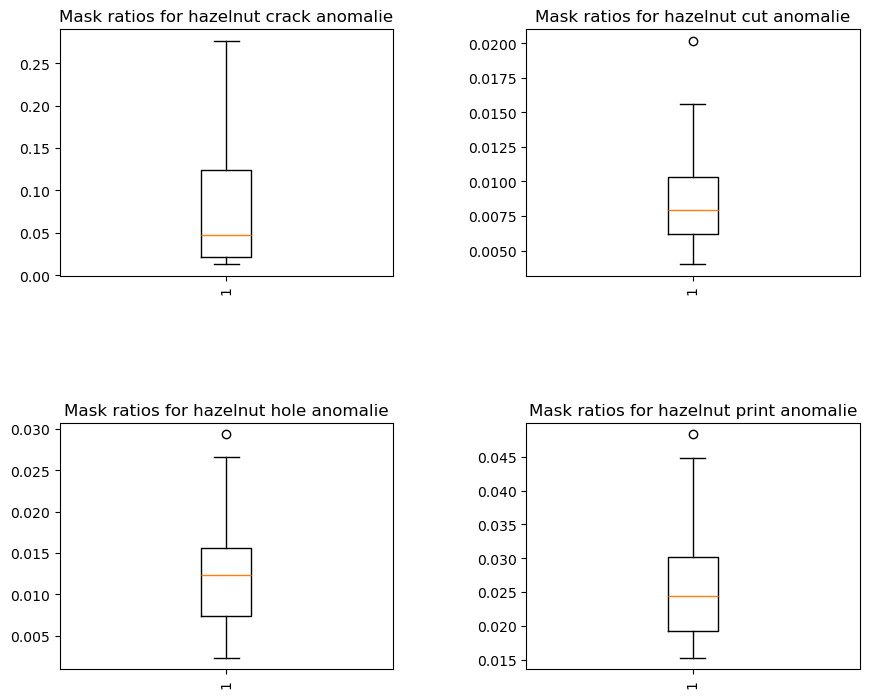

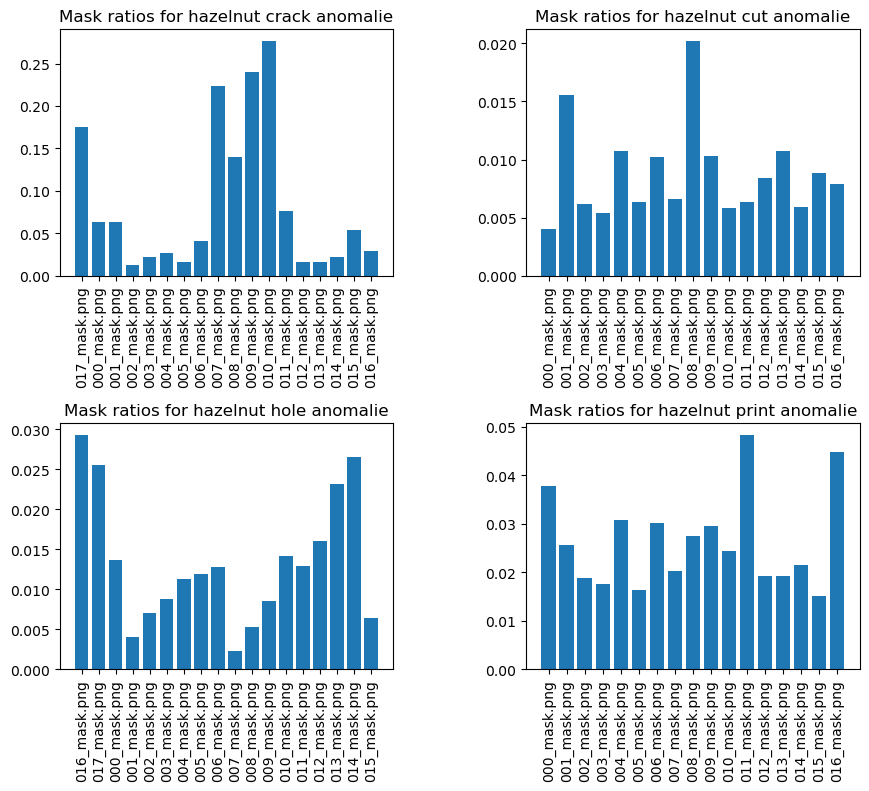

In [26]:
# hazelnut

plot_all_defect_ratios('hazelnut', boxplot=True)
plot_all_defect_ratios('hazelnut', boxplot=False)


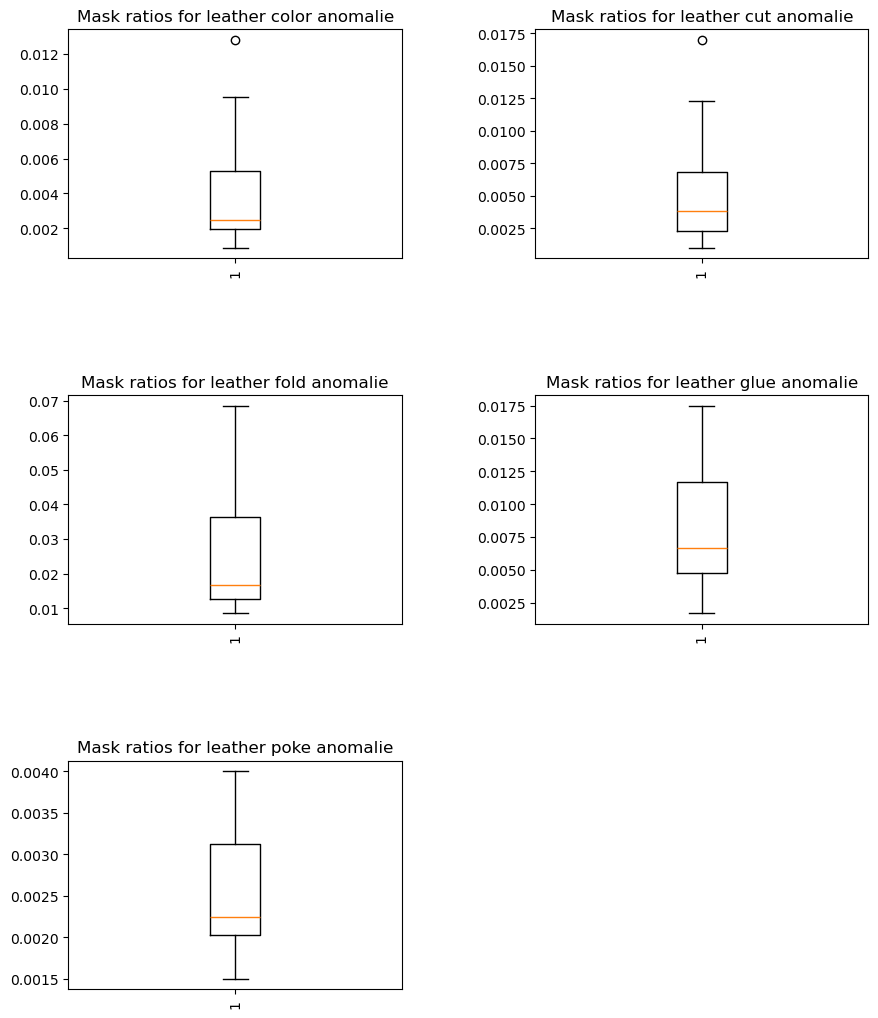

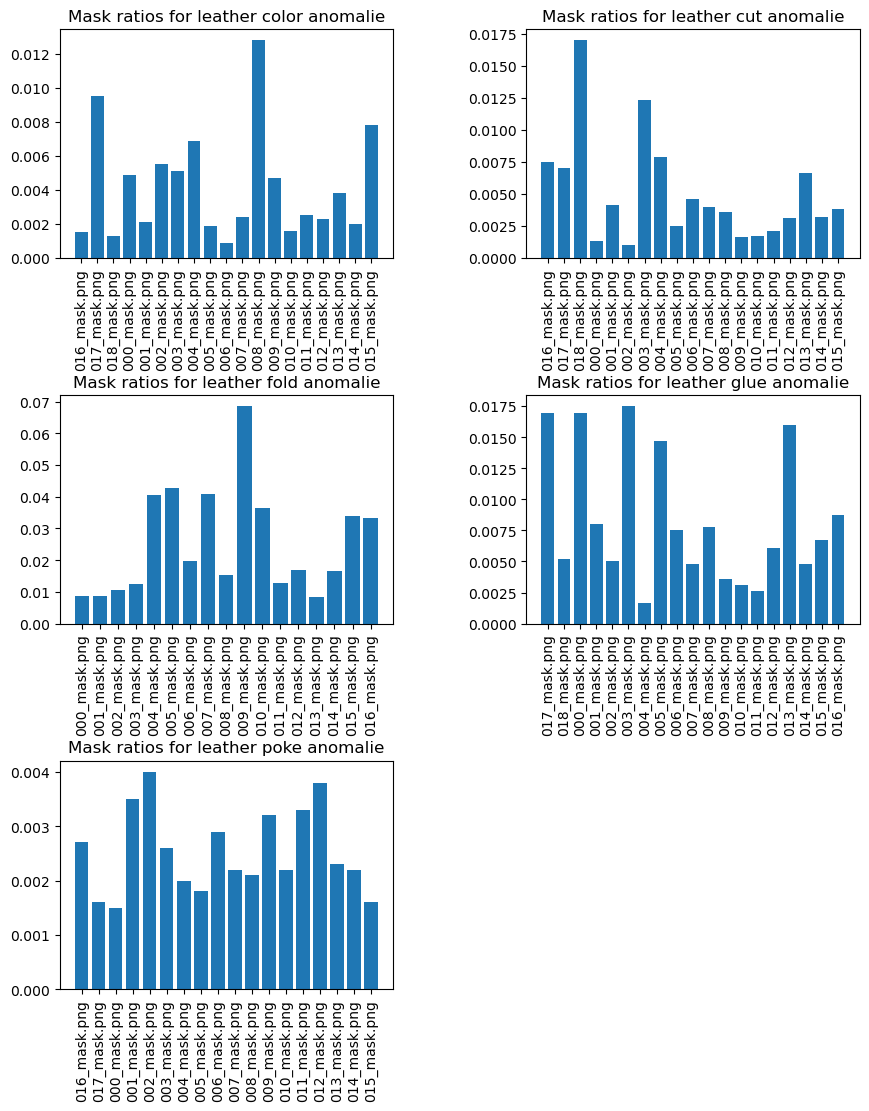

In [19]:
# leather

plot_all_defect_ratios('leather', boxplot=True)
plot_all_defect_ratios('leather', boxplot=False)


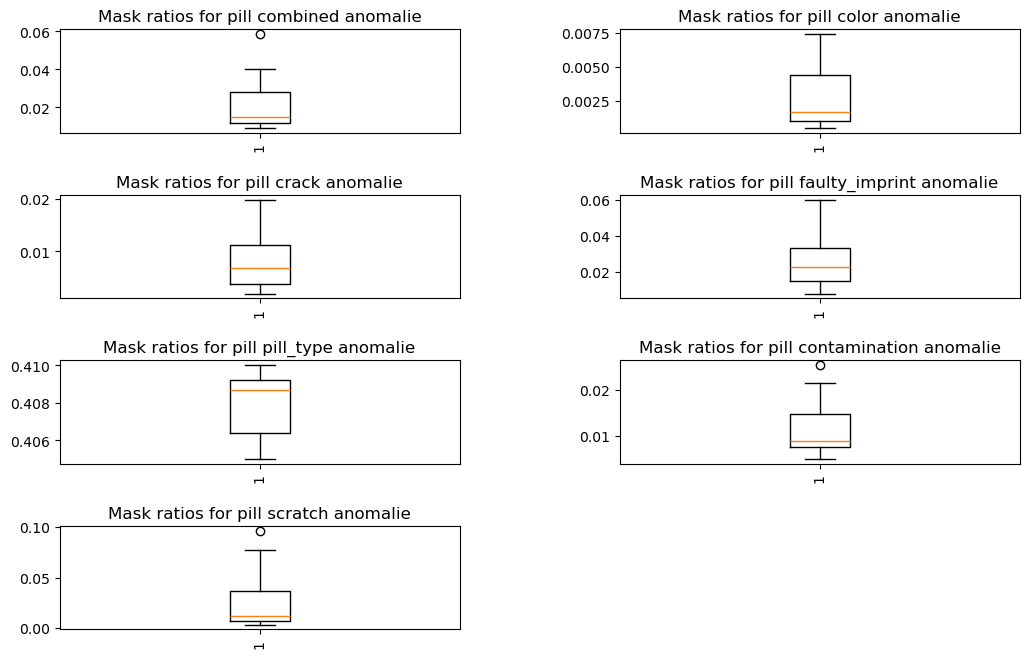

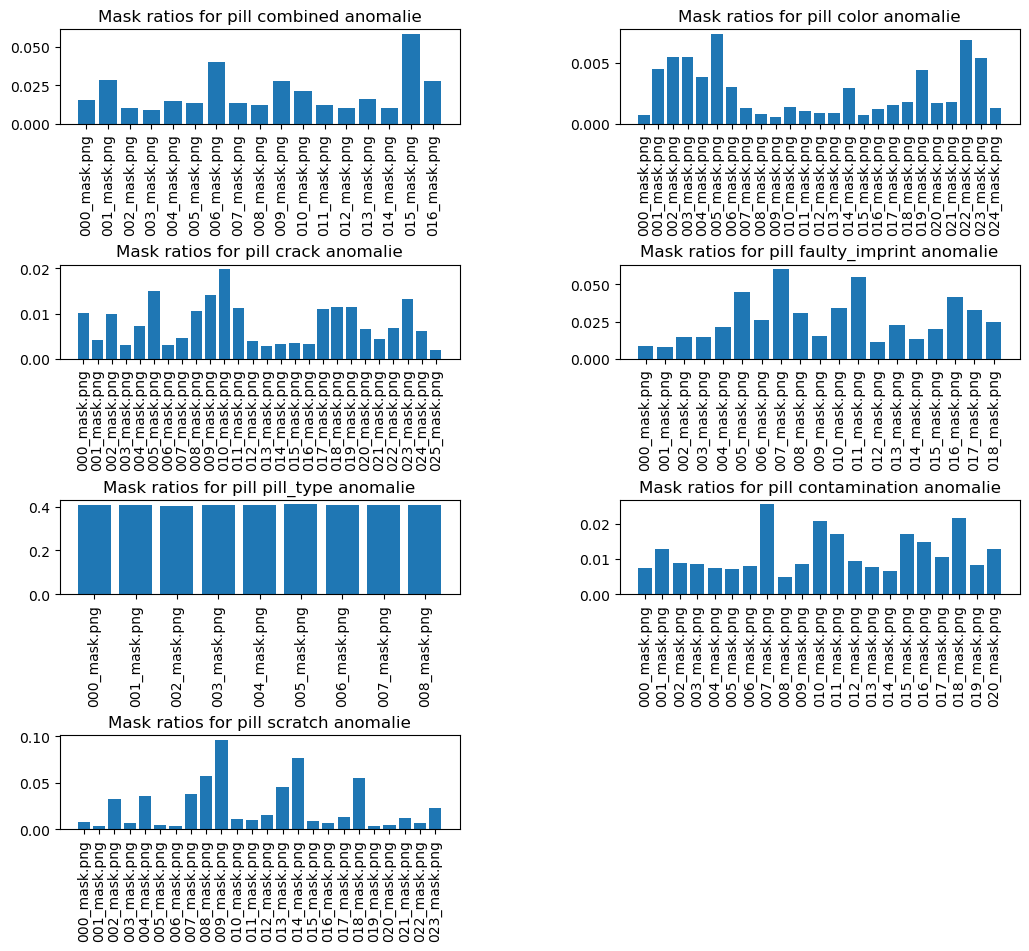

In [35]:
# pill

plot_all_defect_ratios('pill', boxplot=True)
plot_all_defect_ratios('pill', boxplot=False)


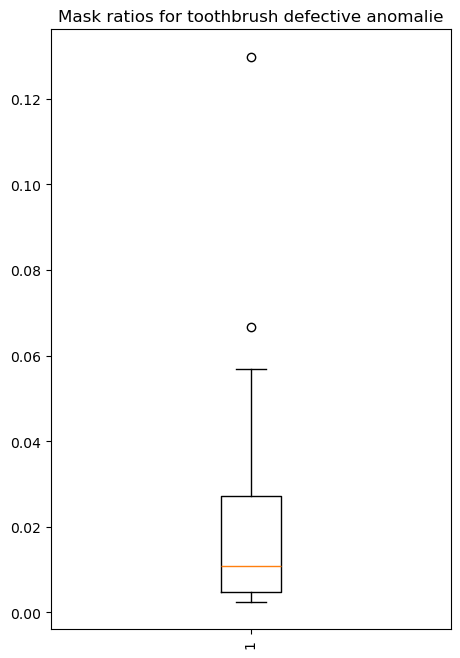

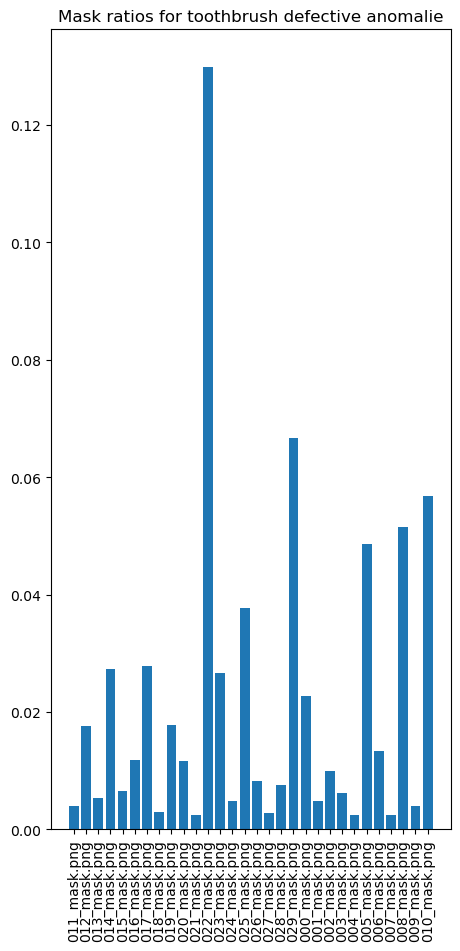

In [36]:
# toothbrush

plot_all_defect_ratios('toothbrush', boxplot=True)
plot_all_defect_ratios('toothbrush', boxplot=False)


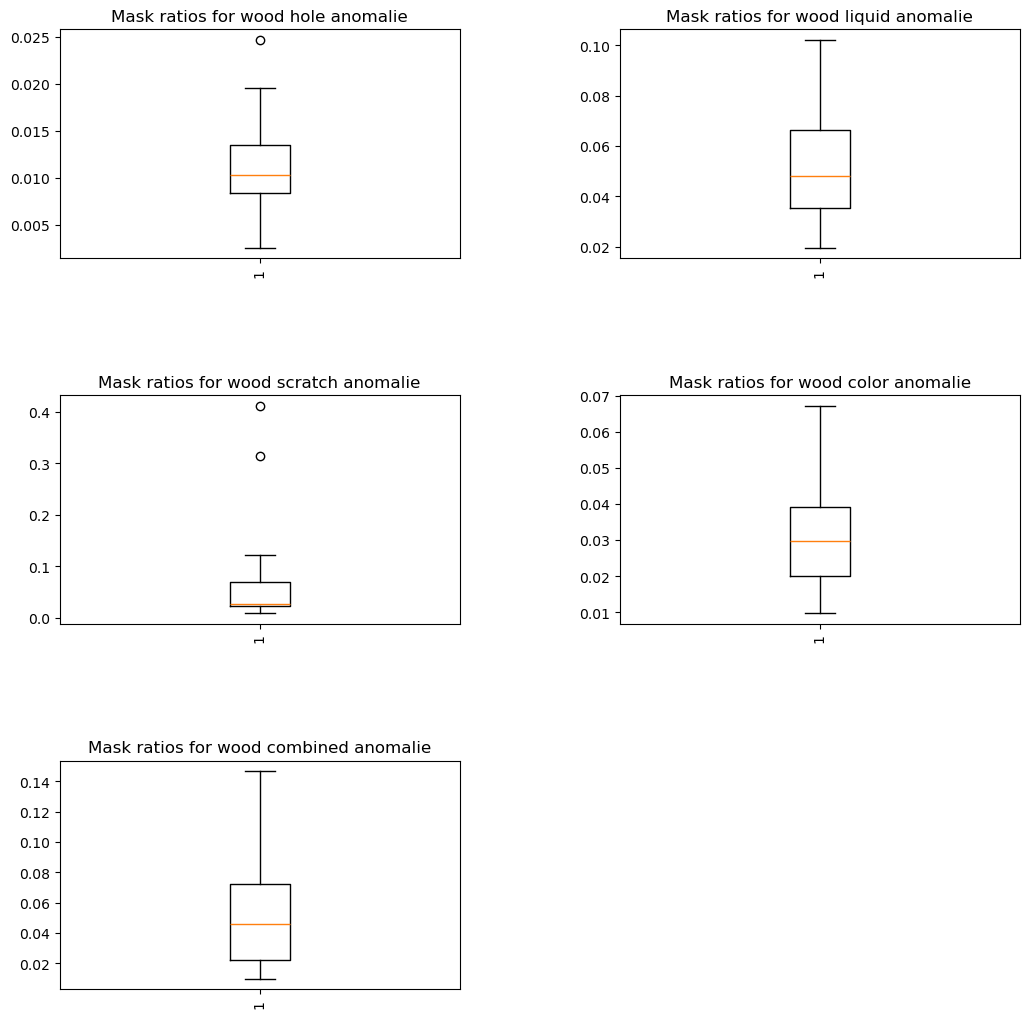

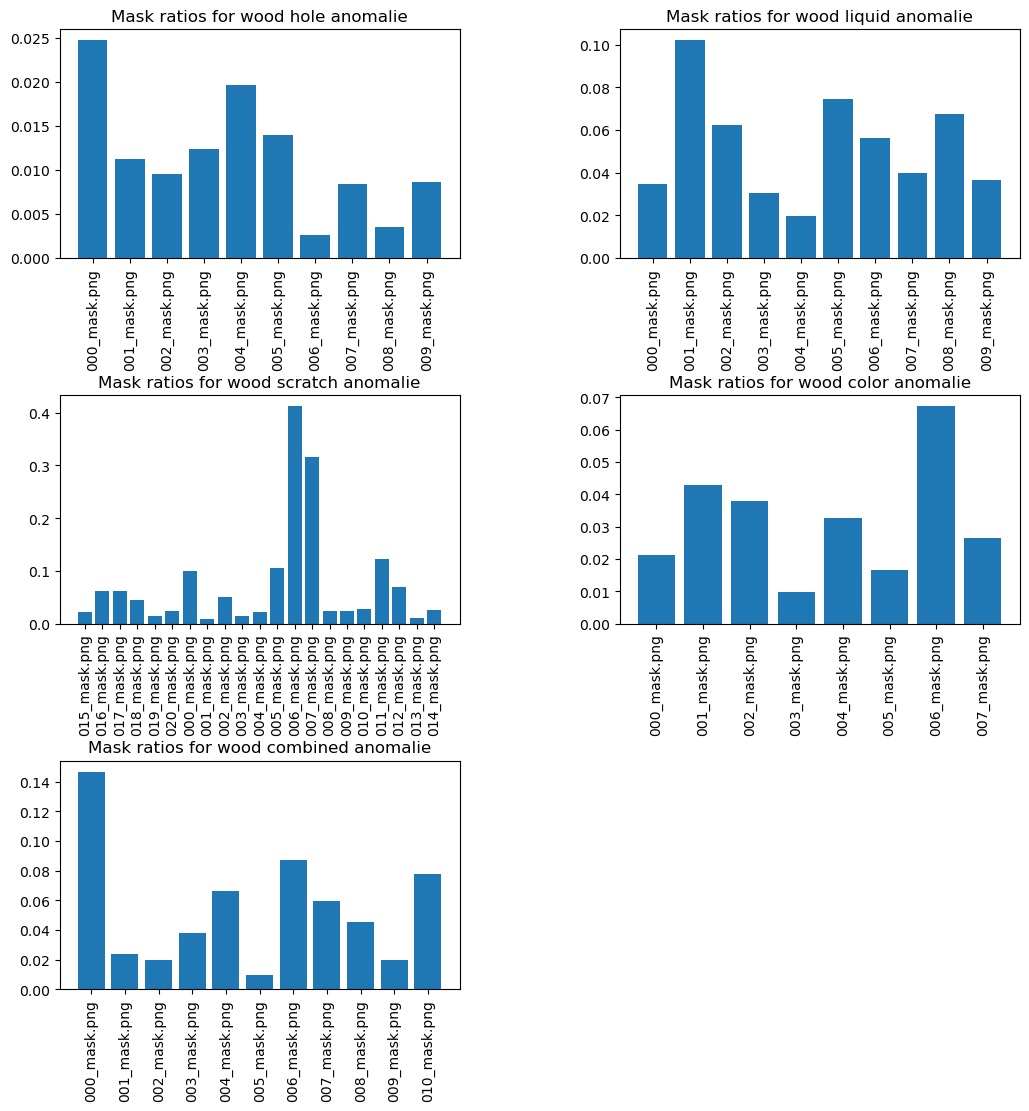

In [23]:
# wood

plot_all_defect_ratios('wood', boxplot=True)
plot_all_defect_ratios('wood', boxplot=False)


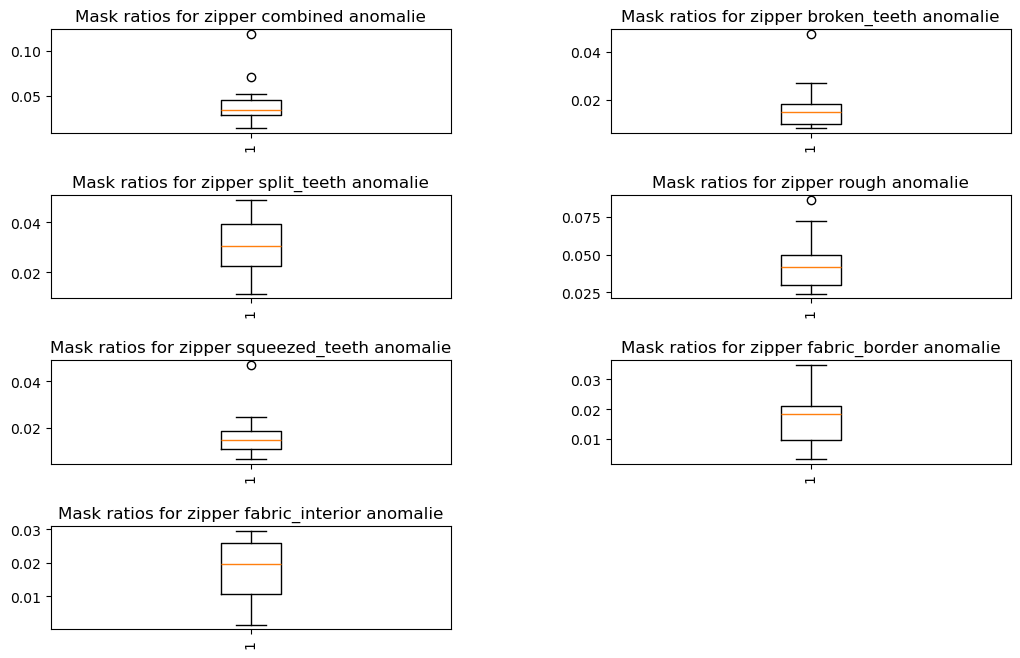

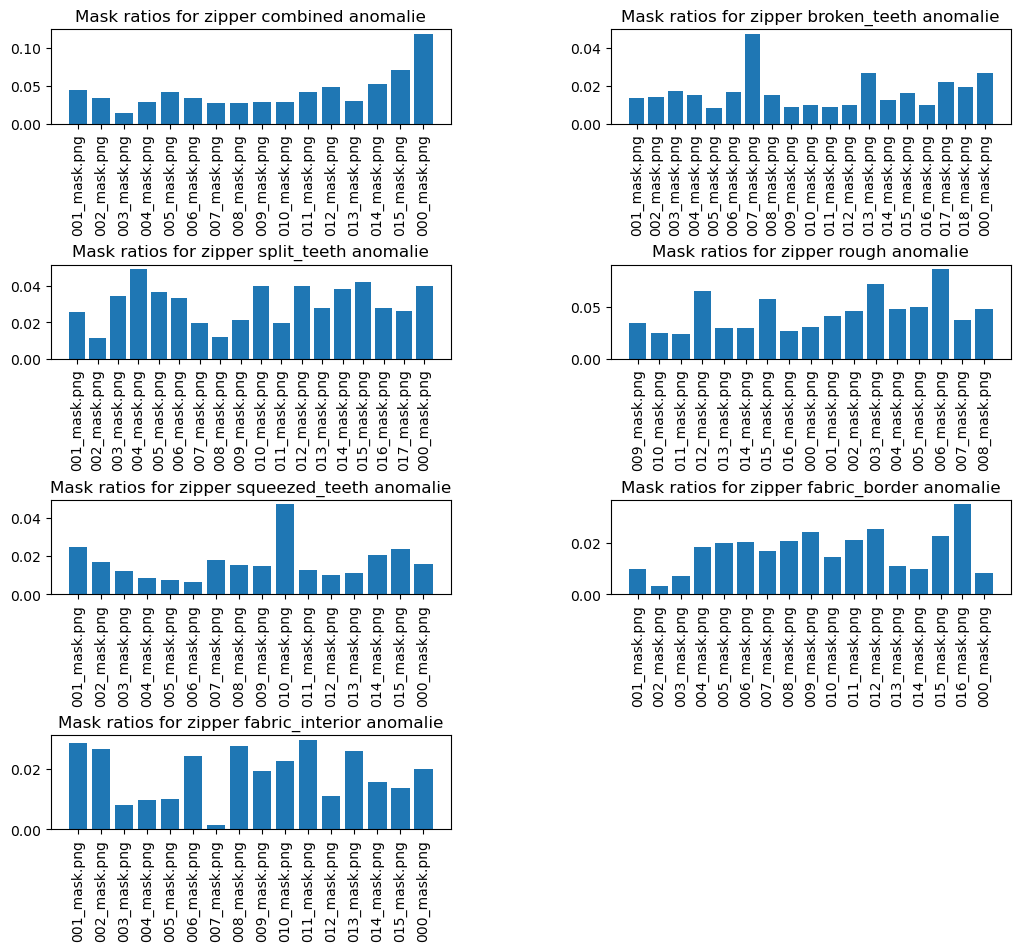

In [37]:
# zipper

plot_all_defect_ratios('zipper', boxplot=True)
plot_all_defect_ratios('zipper', boxplot=False)
